# 5. Model Eğitimi (Random Forest)

Zenginleştirilmiş veri seti ile Random Forest Regressor modeli eğitilmiştir. 

* **Validasyon:** Veri seti %80 Eğitim, %20 Test olarak ayrılmıştır.
* **Model Parametreleri:** Hız ve performans dengesi için `n_estimators=50` seçilmiştir.

In [8]:
features_cols = [
    'Store', 'Dept', 'Type_Encoded', 'Size',      # Mağaza Özellikleri
    'Week', 'Month', 'Year', 'Holiday_Type',      # Zaman ve Tatil 
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', # Ekonomi
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5' # Promosyonlar
]

X = final_dp[features_cols]
y = final_dp['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=50, max_depth=20, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(" Feature Eng. + Random Forest")
print(f"RMSE (Hata Payı): {rmse:.2f} $")
print(f"MAE  (Mutlak Hata): {mae:.2f} $")
print(f"Baseline Farkı: {21820 - rmse:.0f} dolar iyileşme")

 Feature Eng. + Random Forest
RMSE (Hata Payı): 3748.79 $
MAE  (Mutlak Hata): 1497.92 $
Baseline Farkı: 18071 dolar iyileşme


# 7. Evulation



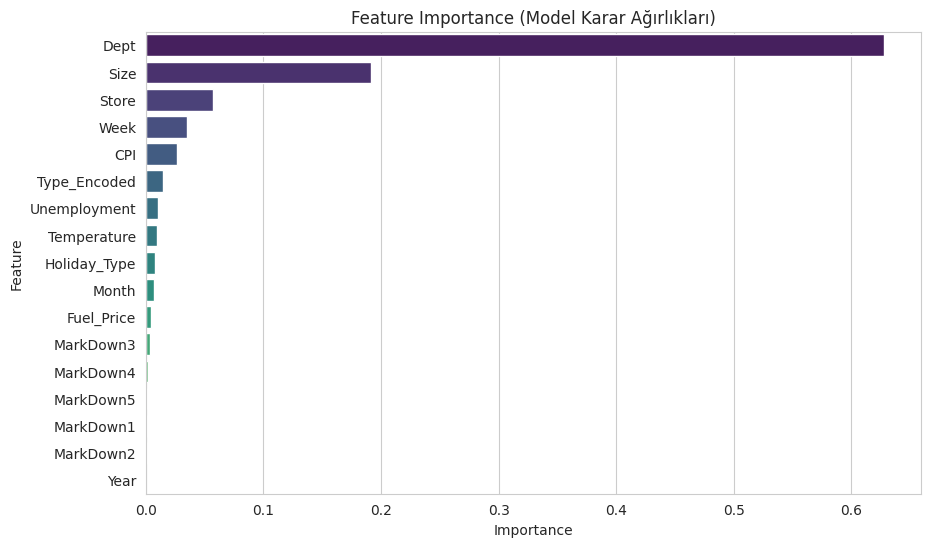

 Final Model Kaydedildi: walmart_rf_model_optimized.pkl


In [10]:
import joblib
# Feature Importance Görselleştirme
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance (Model Karar Ağırlıkları)')
plt.show()

# Modeli Kaydetme
model_filename = 'walmart_rf_model_optimized.pkl'
joblib.dump(best_model, model_filename)

print(f" Final Model Kaydedildi: {model_filename}")
